In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [2]:
@load "metrics_combined.jld2" metrics_combined
@load "dc_delta.jld2" dc_delta
@load "mean_traj_OU.jld2" mean_traj
@load "metrics_redo.jld2" metrics_redo

1-element Vector{Symbol}:
 :metrics_redo

In [2]:
@load "metrics_all.jld2" metrics_all
@load "dc_delta_all.jld2" dc_delta_all


1-element Vector{Symbol}:
 :dc_delta_all

In [2]:
@load "second_redo.jld2" sorted_metrics
@load "dc_delta.jld2" dc_delta

1-element Vector{Symbol}:
 :dc_delta

In [18]:
dc_delta = dc_delta_all[dc_delta_all.n .!= 0.25, :]

Row,tm,n,v,Dc,delta,l,Lambda,eq,threshold
,Int64,Float64,Int64,Float64,Float64,Float64,String15,Int64,Int64
1,1,0.5,10,20.0,0.005,63.2456,"0,158113883",50000,75
2,1,0.75,10,13.3333,0.0075,42.1637,"0,2371708245",50000,75
3,1,1.0,10,10.0,0.01,31.6228,"0,316227766",50000,75
4,1,2.0,10,5.0,0.02,15.8114,"0,632455532",50000,50
5,1,3.0,10,3.33333,0.03,10.5409,"0,9486832981",50000,50
6,1,4.0,10,2.5,0.04,7.90569,"1,264911064",50000,50
7,1,5.0,10,2.0,0.05,6.32456,"1,58113883",50000,50
8,1,6.0,10,1.66667,0.06,5.27046,"1,897366596",50000,50
9,1,7.0,10,1.42857,0.07,4.51754,"2,213594362",50000,50


In [25]:
function simulate_OU(k, D, dt, T, r0)
    nsteps = Int(T/dt)
    r = zeros(nsteps)
    r[1] = r0

    for i in 2:nsteps
        ξ = randn()
        # Standard OU step
        r[i] = r[i-1] - k * r[i-1] * dt + sqrt(2 * D * dt) * ξ
        
        # OPTIONAL: If you strictly need non-negative distance, 
        # use reflection or a softer boundary, not a hard clamp to 0.
        # For now, let's remove the clamp to see the true OU behavior.
        # If r represents displacement, negative values are fine.
        # If r MUST be distance, consider a Bessel process or |r|.
        # r[i] = abs(r[i]) 
    end

    return r
end

function run_simulations_and_get_means(dc_delta, metrics_combined, n_agents=1000, dt=0.01, T=600)
    results = []

    for i in 1:nrow(dc_delta)
        row = dc_delta[i, :]
        v = row[:v]
        tm = row[:tm]
        lambda = row[:n]
        Dc = row[:Dc]
        delta = row[:delta]

        l = sqrt(mean(Dc) / mean(delta))
        r0 = l * 2.5 

        mask = (metrics_combined.v .== v) .& (metrics_combined.l .== lambda) .& (metrics_combined.tm .== tm)

        k = metrics_combined.k[mask][1] / 10



        # CORRECTED FORMULA: Variance = D / k  =>  D = sigma^2 * k
        D = metrics_combined.D[mask][1]

        # Generate 500 trajectories (or n_agents)
        trajectory_sum = zeros(Int(T/dt))

        for agent in 1:n_agents
            traj = simulate_OU(k, D, dt, T, r0)
            trajectory_sum .+= traj
        end

        mean_1 = trajectory_sum / n_agents

        push!(results, Dict(
            :v => v,
            :tm => tm,
            :lambda => lambda,
            :Dc => Dc,
            :delta => delta,
            :k => k,
            :D => D,
            :r0 => r0,
            :mean => mean_1
        ))
    end
   
    df_means = DataFrame(results)
    return df_means
end

run_simulations_and_get_means (generic function with 4 methods)

In [26]:
mean_traj_redo = run_simulations_and_get_means(dc_delta_all, metrics_all)

BoundsError: BoundsError: attempt to access 0-element Vector{Float64} at index [1]

In [15]:
@save "mean_OU_all.jld2" mean_traj_redo

In [3]:
@load "mean_OU_all.jld2" mean_traj_redo


1-element Vector{Symbol}:
 :mean_traj_redo

In [11]:
metrics_all

Row,tm,v,l,mu,sigma,variance,k,D,P_esc
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1.0,5.0,0.25,-0.0196157,7.04843,49.6803,0.115707,5.74836,0.005
2,1.0,10.0,0.25,0.0509994,14.2339,202.605,0.107402,21.7602,0.002
3,1.0,20.0,0.25,0.037579,27.9451,780.943,0.118107,92.2352,0.004
4,1.0,100.0,0.25,0.715938,140.168,19647.4,0.119121,2340.42,0.01
5,2.0,5.0,0.25,0.00929017,9.26406,85.823,0.0892695,7.66138,0.02
6,2.0,10.0,0.25,0.197182,18.5718,344.923,0.092583,31.934,0.005
7,2.0,20.0,0.25,-0.0761863,37.3084,1391.92,0.0866209,120.569,0.01
8,2.0,100.0,0.25,1.2922,183.589,33704.9,0.0908656,3062.62,0.019
9,4.0,5.0,0.25,0.589631,14.6605,214.955,0.0741803,15.9454,0.407


In [30]:
df = combined_dfs[(20.0, 0.25)]
grouped = groupby(df, :step)
mean(grouped[1].x)

631.8021688807576

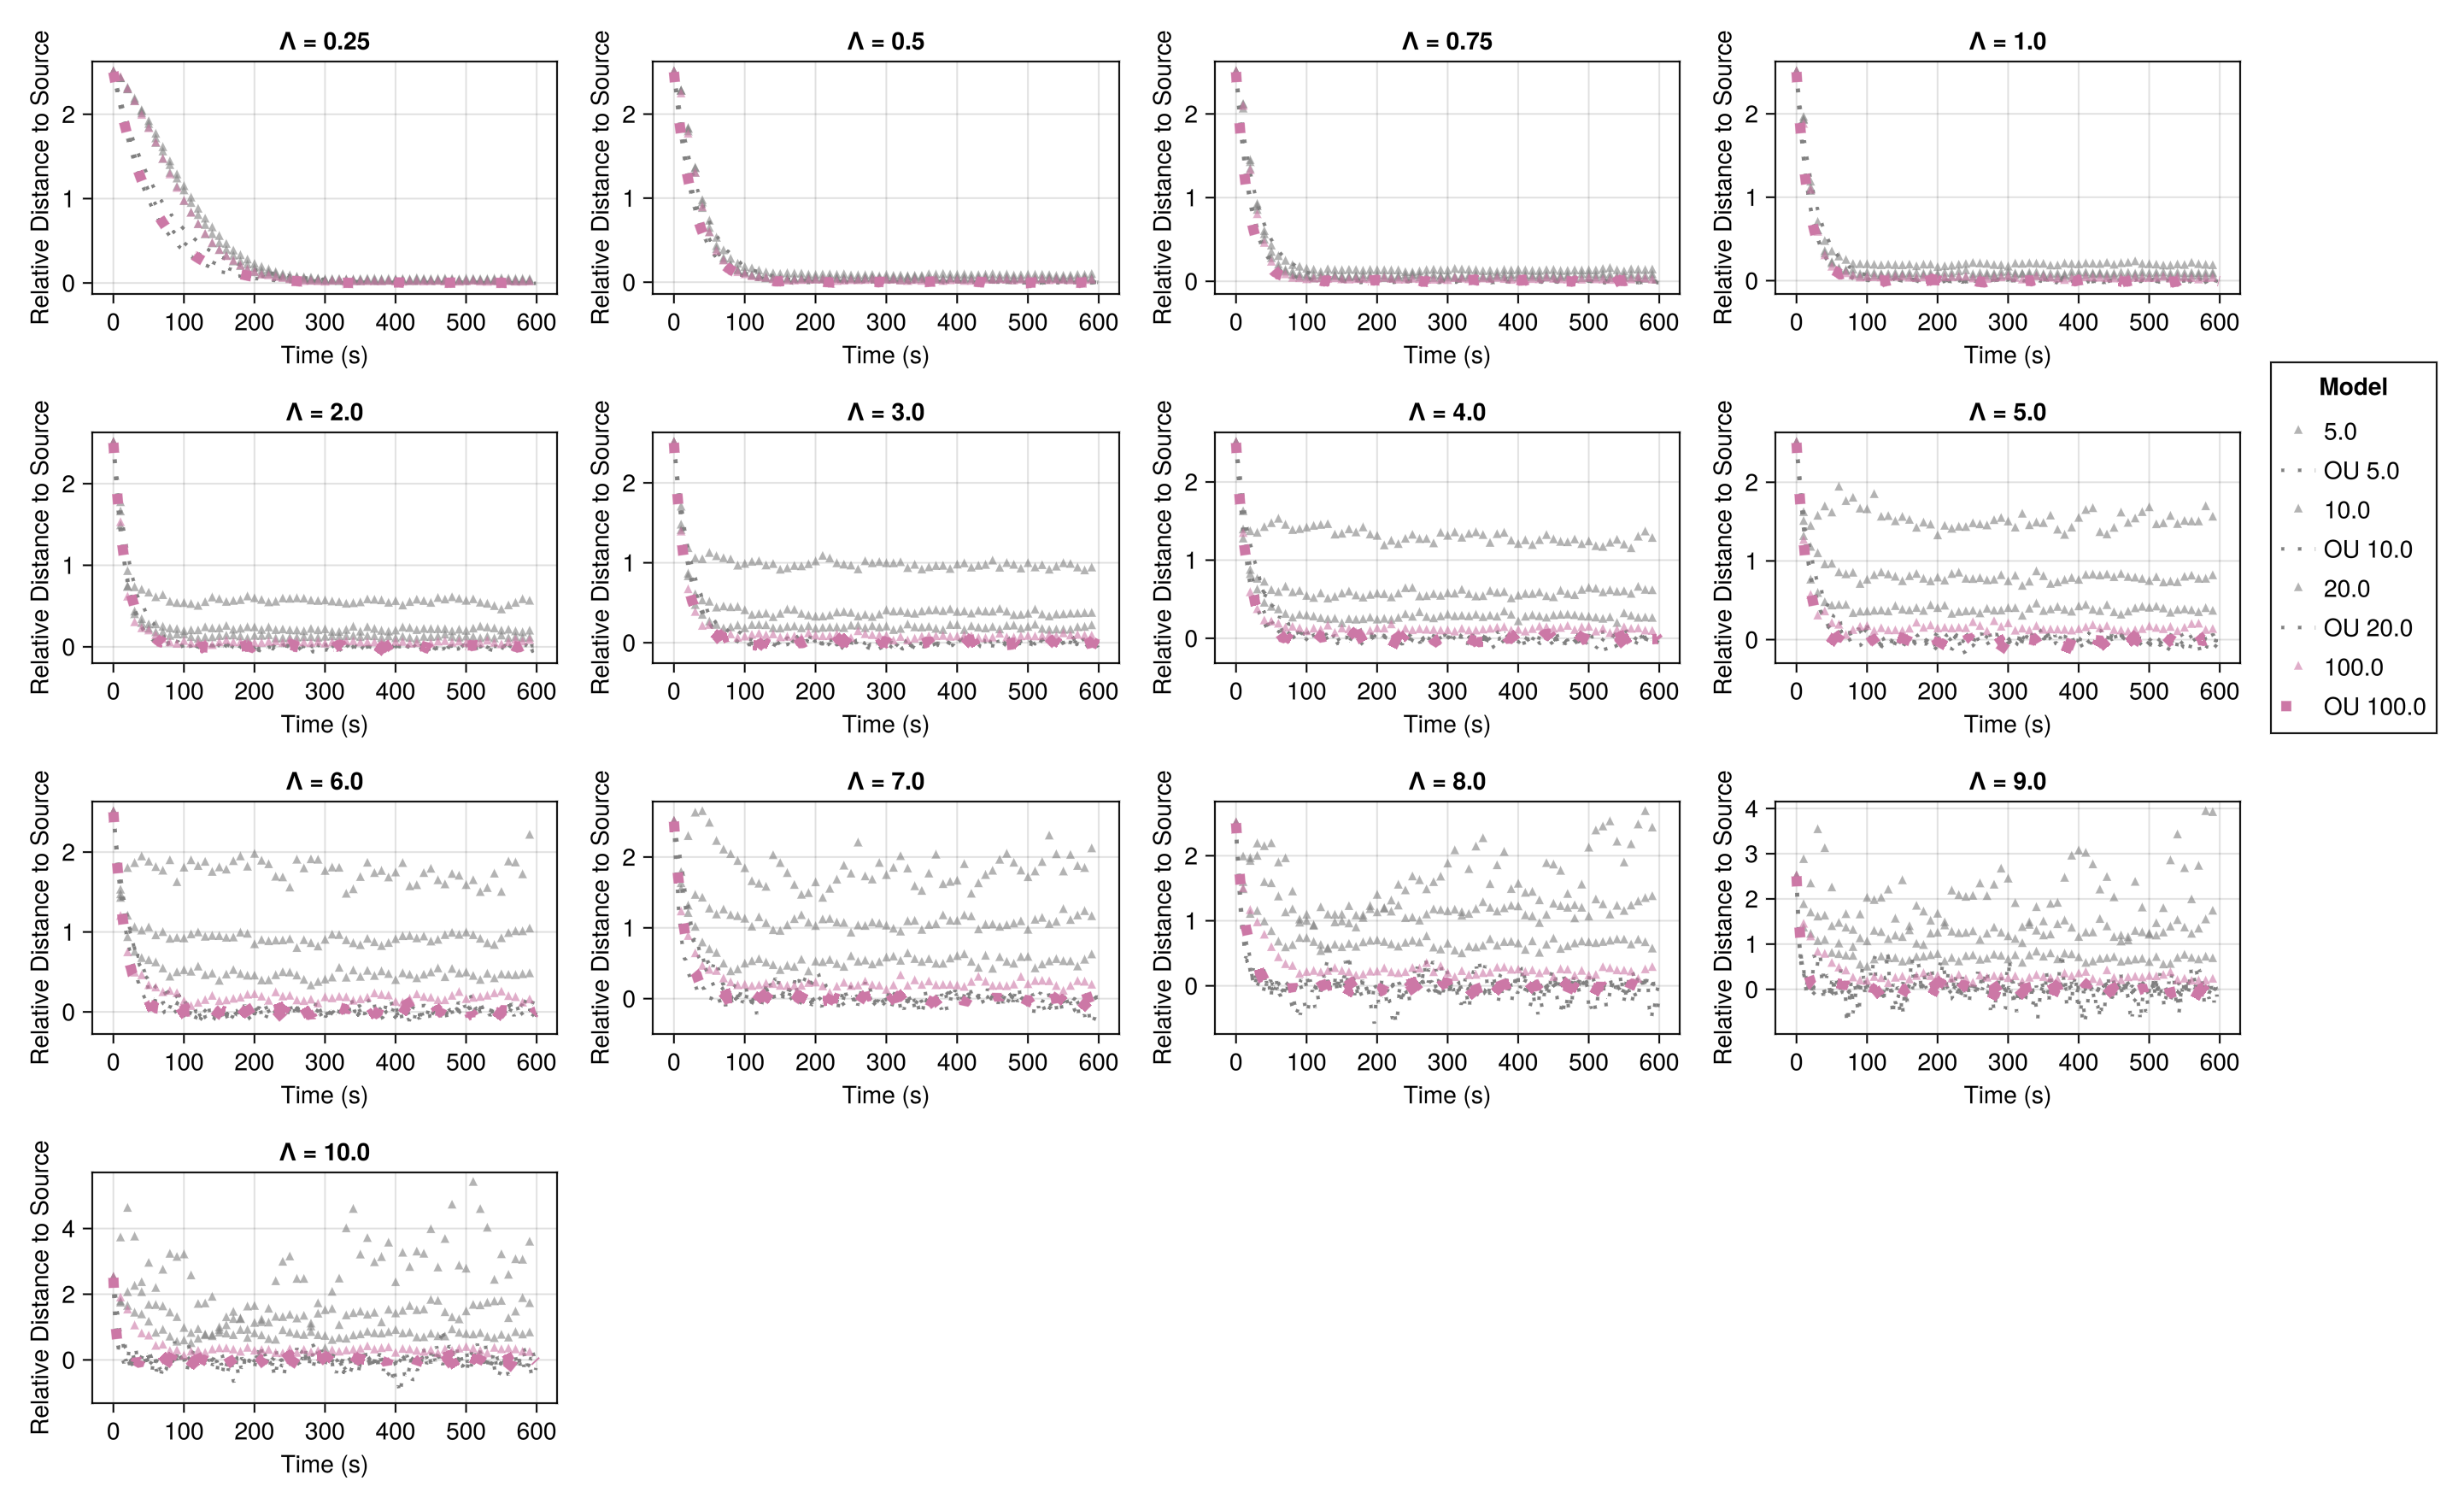

GLMakie.Screen(...)

In [10]:
# lambdas = [0.25, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000

velocities = [5.0, 10.0, 20.0, 100.0]
# velocities = [5.0]
# velocities = [10.0]
# velocities = [20.0]
# velocities = [100.0]
thresholds = [40, 75, 275, 850]
# thresholds = [40]
# thresholds = [75]
# thresholds = [275]
# thresholds = [850]

# colors = distinguishable_colors(4, [RGB(1,1, 1), RGB(0, 0, 0)], dropseed = true, lchoices=range(70, stop=95, length = 15), cchoices=range(10, stop=40, length=15))
# colors = distinguishable_colors(
#     4,
#     [RGB(1,1,1), RGB(0,0,0)],
#     dropseed = true,
#     lchoices = range(50, stop=85, length=20),
#     cchoices = range(30, stop=80, length=20)
# )
# id_to_color = Dict(1:4 .=> colors)
# colors = [
#     RGBf(0.0, 0.45, 0.70),   # blue
#     RGBf(0.90, 0.62, 0.0),   # orange
#     RGBf(0.0, 0.62, 0.45),   # green
#     RGBf(0.80, 0.47, 0.65)   # magenta
# ]
colors = [
    :grey,   # blue
    :grey,   # orange
    :grey,  # green
    RGBf(0.80, 0.47, 0.65) # magenta
]
# colors = [:red, :blue, :green, :yellow]
# colors_2 = [:pink, :black, :brown, :orange]

# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig2 = Figure(size=(900 * cols, 600 * rows))

widths = [2, 2, 2, 6]


for (idx, lambda) in enumerate(lambdas)
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax_x = Axis(fig2[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")

    
    for (v_idx, v) in enumerate(velocities)

        df = combined_dfs[(v, lambda)]

        color = colors[v_idx]

        mean_x = Float64[]
        mean_y = Float64[]

        mask = (dc_delta.v .== v) .& (dc_delta.lambda .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        # l = sqrt(Dc/delta)
        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        eq = grouped[3000:end]
        df_subset = DataFrame(eq)

        if lambda < 6.0

            bad_rows_mask = (df_subset.x .> thresholds[v_idx]) .| (df_subset.y .>  thresholds[v_idx]) .| (df_subset.x .< -thresholds[v_idx]) .| (df_subset.y .< - thresholds[v_idx])
        else
            t = (thresholds[v_idx])/2
            bad_rows_mask = (df_subset.x .> thresholds[v_idx]) .| (df_subset.y .>  thresholds[v_idx]) .| (df_subset.x .< -thresholds[v_idx]) .| (df_subset.y .< - thresholds[v_idx])
        end

        bad_agents = unique(df_subset[bad_rows_mask, :agent])

        df_clean = filter(row -> !(row.agent in bad_agents), df)

        if isempty(df_clean)
            @warn "No data for v=$v, lambda=$lambda. Skipping."
            continue
        end

        grouped_t = groupby(df_clean, :step)
        
        if isempty(grouped_t)
             @warn "No steps found in filtered data."
             continue
        end


        for i in 1:100:length(grouped_t)
            data_1 = grouped_t[i]
            x = data_1.x ./l
            y = data_1.y ./l

            # r = sqrt.(data_1.x .^ 2 .+ data_1.y .^ 2)
            # rl = r ./l

            push!(mean_x, mean(x))
            push!(mean_y, mean(x))
        end

        mask = (mean_traj.lambda .== lambda) .& (mean_traj.v .== v) 

        mean_OU = mean_traj.mean[mask]
        mean_OUl = mean_OU ./ l 
        flat_vec = vcat(mean_OUl...)
        idx_l = 1:100:length(flat_vec)
        scatter!(ax_x, (1:100:length(grouped_t))*0.1, mean_x, color = color, label = "$v", alpha = 0.6, marker = :utriangle, markersize = 7, strokecolor = :black)
        lines!(ax_x, (1:100:length(flat_vec))*0.01, flat_vec[idx_l], color = color, linestyle = (:dot, :loose), linewidth = widths[v_idx], label = "OU $v")


        if idx == 13 & v_idx == 4
            fig2[2,5] = Legend(fig2, ax_x, "Model")
        end
    end
end

display(fig2)

In [11]:
save("Plots/Fixed_source_model/OU/OU_all_v100.png", fig2)

In [11]:
@load "redo_dfs.jld2" dfs_redo

1-element Vector{Symbol}:
 :dfs_redo

In [27]:
tm2 = mean_traj_redo[mean_traj_redo.tm .== 4.0, :]
v20 = tm2[tm2.v .== 20.0, :]

Row,lambda,mean,k,v,D,tm,Dc,delta,r0
,Float64,Array…,Float64,Int64,Float64,Int64,Float64,Float64,Float64
1,0.5,"[1264.91, 1263.97, 1262.88, 1261.76, 1260.67, 1259.58, 1258.42, 1257.36, 1256.27, 1255.24 … -0.637178, -0.667097, -0.663241, -0.637703, -0.615678, -0.642472, -0.590394, -0.552221, -0.488512, -0.536024]",0.0842506,20,151.277,4,20.0,7.8125e-5,1264.91
2,0.75,"[843.274, 842.485, 841.712, 840.998, 840.223, 839.479, 838.729, 837.927, 837.132, 836.282 … -1.69672, -1.68043, -1.65051, -1.66684, -1.62895, -1.59402, -1.62964, -1.60881, -1.64925, -1.68473]",0.0905378,20,134.766,4,13.3333,0.000117187,843.274
3,1.0,"[632.456, 631.937, 631.375, 630.687, 630.07, 629.47, 628.784, 628.251, 627.599, 626.914 … -1.10935, -1.13326, -1.08986, -1.05156, -0.996863, -1.005, -0.931606, -0.817059, -0.822, -0.867354]",0.0985115,20,125.015,4,10.0,0.00015625,632.456
4,2.0,"[316.228, 315.849, 315.504, 315.18, 314.841, 314.446, 314.068, 313.781, 313.446, 313.116 … 0.343485, 0.335418, 0.404705, 0.460768, 0.504234, 0.500305, 0.533475, 0.497565, 0.593096, 0.577257]",0.111731,20,106.163,4,5.0,0.0003125,316.228
5,3.0,"[210.819, 210.575, 210.237, 209.96, 209.749, 209.634, 209.425, 209.2, 208.935, 208.738 … -0.540138, -0.51712, -0.46053, -0.521329, -0.619621, -0.689947, -0.653033, -0.70771, -0.723965, -0.722534]",0.116598,20,93.0329,4,3.33333,0.00046875,210.819
6,4.0,"[158.114, 157.906, 157.729, 157.597, 157.382, 157.198, 157.047, 156.873, 156.777, 156.653 … -0.641163, -0.657864, -0.630065, -0.615734, -0.597791, -0.654926, -0.652122, -0.591596, -0.63725, -0.675832]",0.11518,20,81.7706,4,2.5,0.000625,158.114
7,5.0,"[126.491, 126.365, 126.247, 126.164, 126.088, 125.929, 125.776, 125.64, 125.569, 125.419 … 0.472658, 0.467037, 0.491661, 0.522198, 0.50948, 0.517044, 0.572993, 0.573309, 0.591456, 0.542669]",0.11767,20,76.0518,4,2.0,0.00078125,126.491
8,6.0,"[105.409, 105.341, 105.217, 105.136, 105.08, 104.997, 104.868, 104.734, 104.558, 104.453 … 0.886248, 0.871107, 0.803539, 0.843717, 0.826036, 0.791675, 0.757159, 0.8027, 0.729891, 0.752662]",0.117384,20,69.6489,4,1.66667,0.0009375,105.409
9,7.0,"[90.3508, 90.2304, 90.0944, 90.0071, 89.9017, 89.8463, 89.7394, 89.5855, 89.5147, 89.4092 … -1.29275, -1.30687, -1.33992, -1.35981, -1.35916, -1.34665, -1.31064, -1.37154, -1.33787, -1.39779]",0.119353,20,67.2078,4,1.42857,0.00109375,90.3508


In [4]:
@load "dfs_all.jld2" dfs_all


1-element Vector{Symbol}:
 :dfs_all

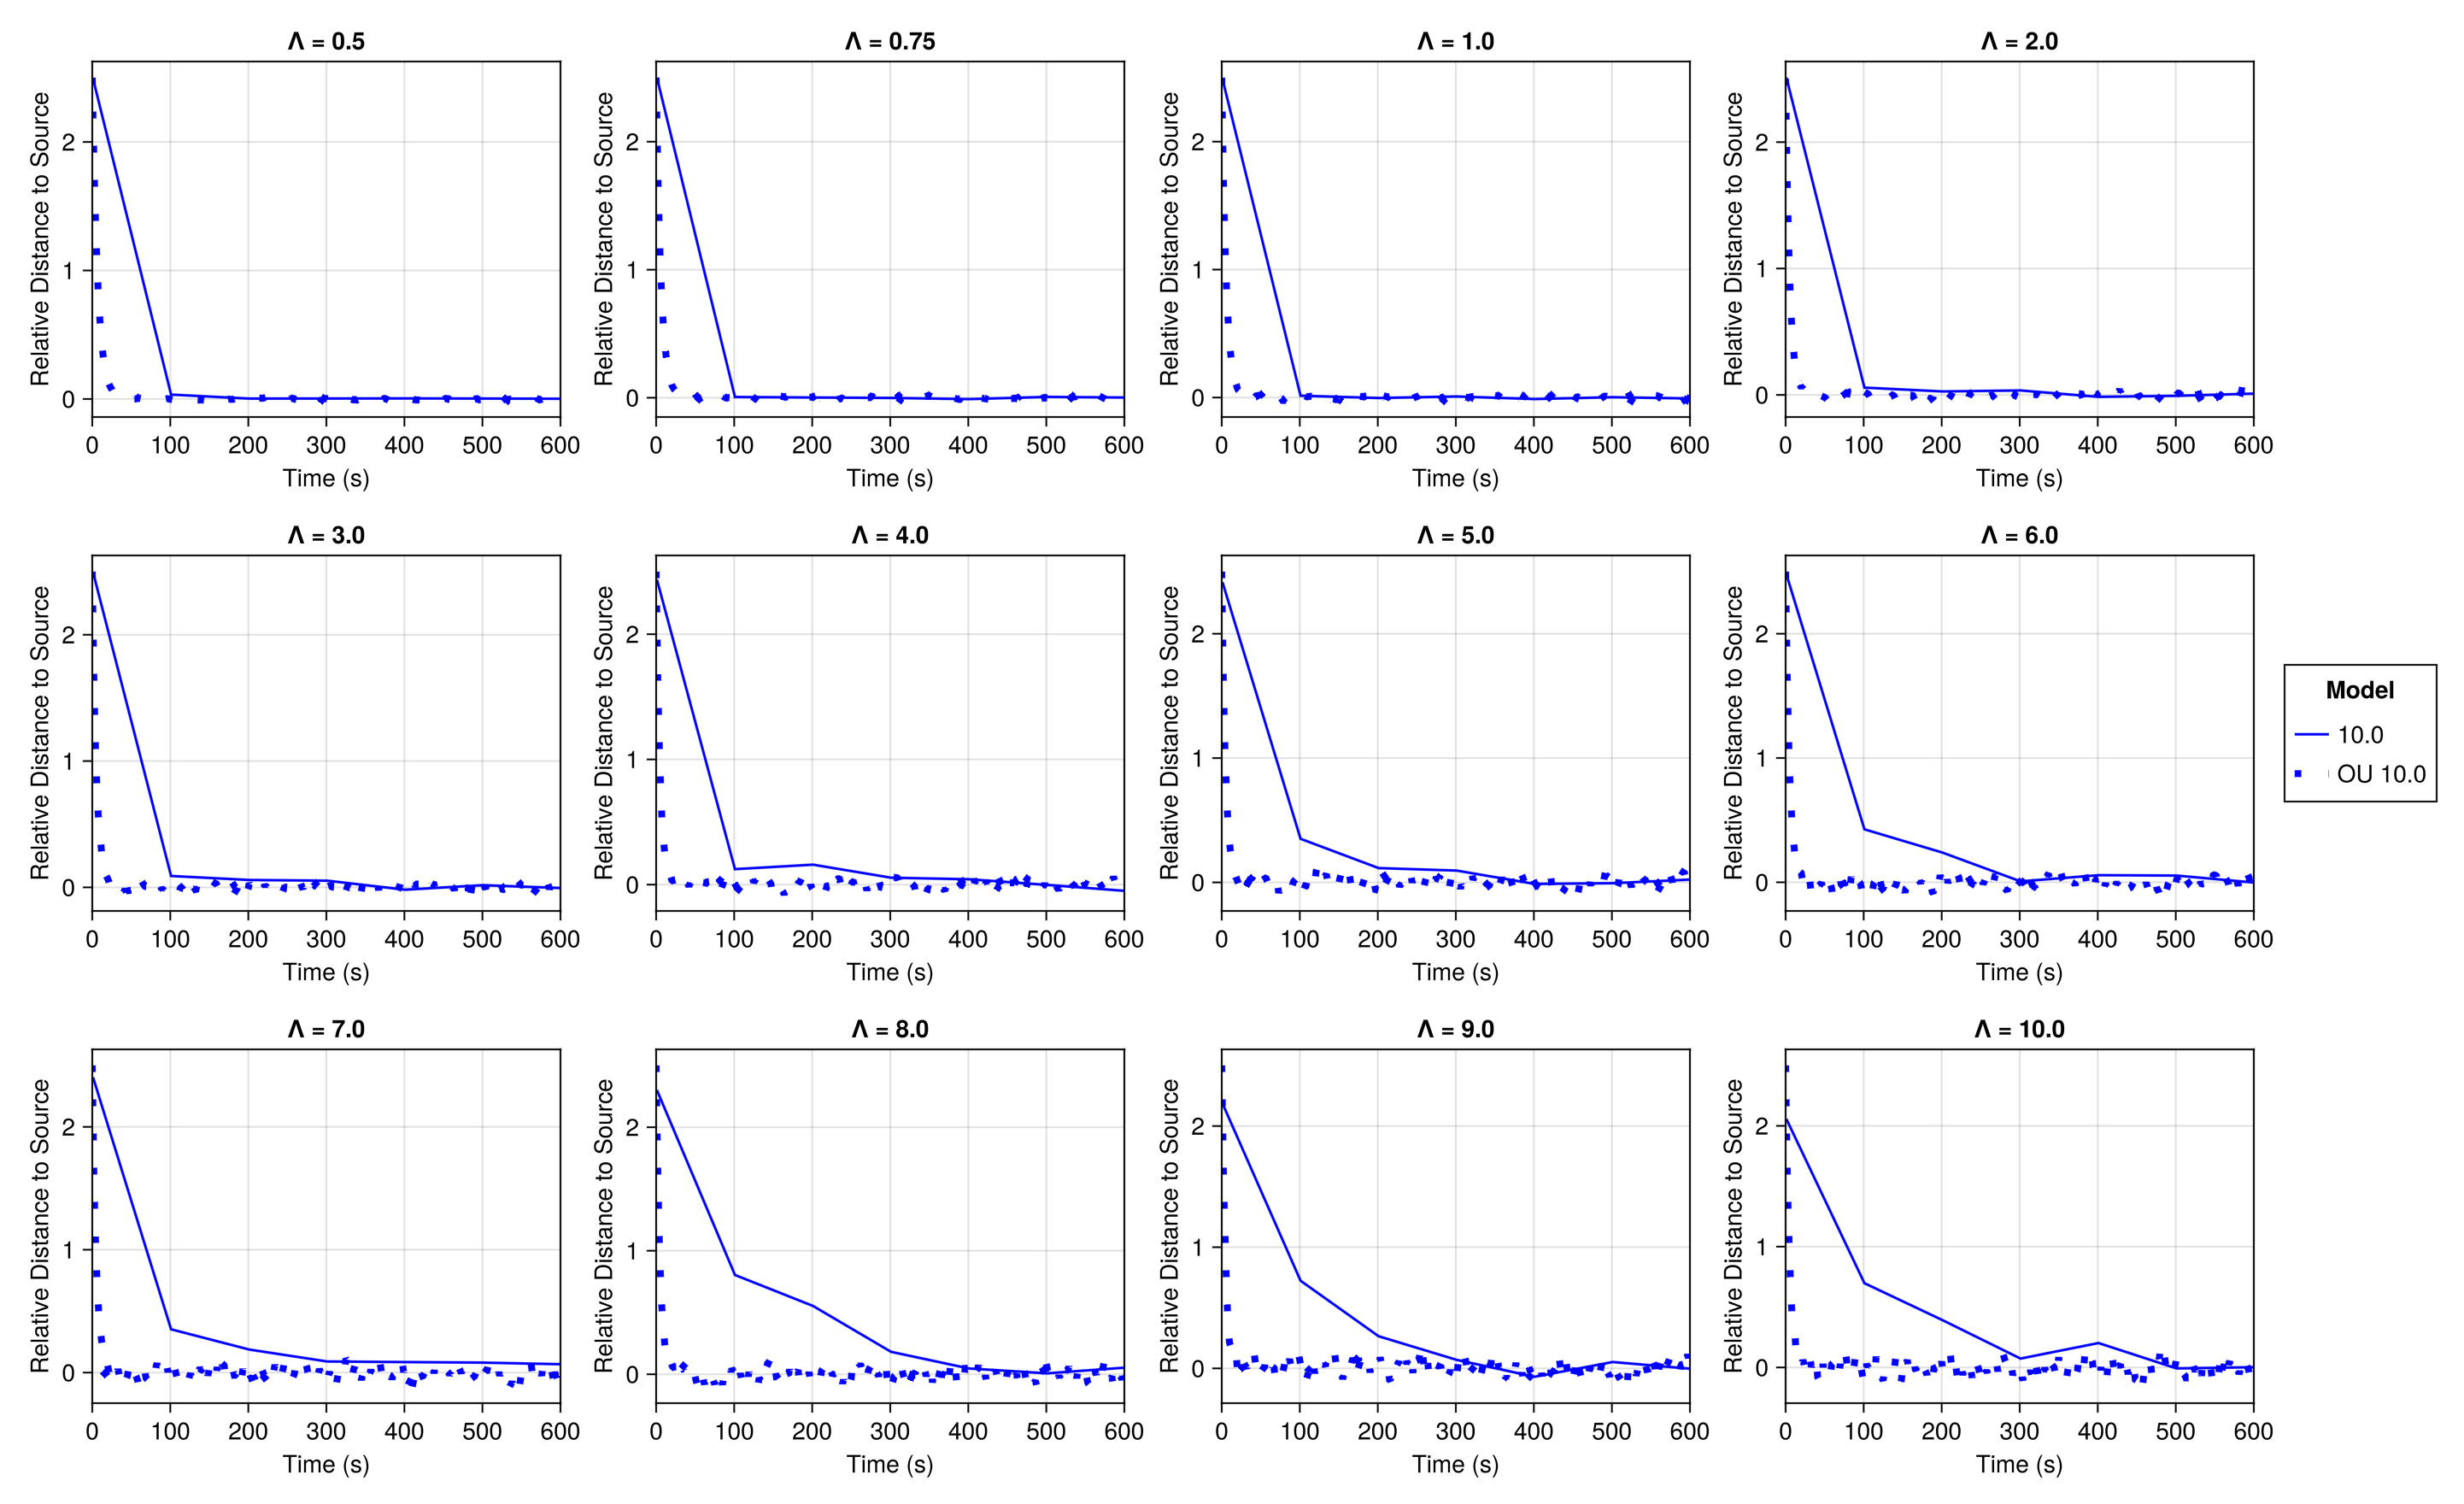

GLMakie.Screen(...)

In [30]:
# lambdas = [0.25, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
lambdas = [0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000


# velocities = [5.0]
# velocities = [10.0]
velocities = [10.0]
# velocities = [100.0]

# id_to_color = Dict(1:4 .=> colors)
# colors = [
#     RGBf(0.0, 0.45, 0.70),   # blue
#     RGBf(0.90, 0.62, 0.0),   # orange
#     RGBf(0.0, 0.62, 0.45),   # green
#     RGBf(0.80, 0.47, 0.65)   # magenta
# ]
colors = [
    :blue
]


# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig2 = Figure(size=(900 * cols, 600 * rows))

for (idx, lambda) in enumerate(lambdas)
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax_x = Axis(fig2[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")

    
    for (v_idx, v) in enumerate(velocities)

        df = dfs_all[(1.0, v, lambda)]

        color = colors[v_idx]

        mean_x = Float64[]
        mean_y = Float64[]

        mask = (dc_delta_all.v .== v) .& (dc_delta_all.n .== lambda) .& (dc_delta_all.tm .== 1.0)
        
        Dc = dc_delta_all.Dc[mask]

        delta = dc_delta_all.delta[mask]

        # l = sqrt(Dc/delta)
        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        for i in 1:100:length(grouped)
            data_1 = grouped[i]
            x = data_1.x ./l
            y = data_1.y ./l

            # r = sqrt.(data_1.x .^ 2 .+ data_1.y .^ 2)
            # rl = r ./l

            push!(mean_x, mean(x))
            push!(mean_y, mean(x))
        end

        mask = (mean_traj_redo.lambda .== lambda) .& (mean_traj_redo.v .== v) .& (mean_traj_redo.tm .== 1.0)

        mean_OU = mean_traj_redo.mean[mask]
        mean_OUl = mean_OU ./ l 
        flat_vec = vcat(mean_OUl...)
        idx_l = 1:100:length(flat_vec)
        lines!(ax_x, (1:100:length(grouped)), mean_x, color = color, label = "$v")
        lines!(ax_x, (1:100:length(flat_vec))*0.01, flat_vec[idx_l], color = color, linestyle = (:dot, :loose), linewidth = 4, label = "OU $v")
        xlims!(ax_x, 0, 600)

        if idx == 13 & v_idx == 1
            fig2[2,5] = Legend(fig2, ax_x, "Model")
        end
    end
end

display(fig2)

In [21]:
save("Plots/Fixed_source_model/Next/OU_v20_new.png", fig2)

In [42]:
@save "mean_traj_OU.jld2" mean_traj

In [5]:
@load "mean_traj_OU.jld2" mean_traj

1-element Vector{Symbol}:
 :mean_traj

In [ ]:
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000

velocities = [5.0, 10.0, 20.0, 100.0]
# velocities = [5.0]
# velocities = [10.0]
# velocities = [20.0]
# velocities = [100.0]
# thresholds = [40, 75, 275, 850]
# thresholds = [40]
# thresholds = [75]
# thresholds = [275]
# thresholds = [850]

colors = [
    RGBf(0.0, 0.45, 0.70),   # blue
    RGBf(0.90, 0.62, 0.0),   # orange
    RGBf(0.0, 0.62, 0.45),   # green
    RGBf(0.80, 0.47, 0.65)   # magenta
]

# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig2 = Figure(size=(900 * cols, 600 * rows))


for (idx, lambda) in enumerate(lambdas)
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax_x = Axis(fig2[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")

    
    for (v_idx, v) in enumerate(velocities)

        df = dfs_redo[(v, lambda)]

        color = colors[v_idx]

        mean_x = Float64[]
        mean_y = Float64[]

        mask = (dc_delta.v .== v) .& (dc_delta.lambda .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        for i in 1:100:length(grouped)
            data_1 = grouped[i]
            x = data_1.x ./l
            y = data_1.y ./l

            push!(mean_x, mean(x))
            push!(mean_y, mean(x))
        end

        mask = (mean_traj_redo.lambda .== lambda) .& (mean_traj_redo.v .== v) 

        mean_OU = mean_traj_redo.mean[mask]
        mean_OU_norm = mean_OU ./ l 
        flat_vec = vcat(mean_OU_norm...)
        idx_l = 1:100:length(flat_vec)
        lines!(ax_x, (1:100:length(grouped))*0.1, mean_x, color = color, label = "$v")
        lines!(ax_x, (1:100:length(flat_vec))*0.01, flat_vec[idx_l], color = color, linestyle = (:dot, :loose), linewidth = 5, label = "OU $v")


        if idx == 13 & v_idx == 4
            fig2[2,5] = Legend(fig2, ax_x, "Model")
        end
    end
end

display(fig2)